## Model Training

#### 1.1 Import Data and Required Packages
##### Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [1]:
# 
from typing import Dict

# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# Modelling
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV, train_test_split

# Data Transformation
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# algorithms
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

# validation
from sklearn.model_selection import KFold, cross_validate

# others
import warnings

#### Import the CSV Data as Pandas DataFrame

In [2]:
df = pd.read_csv("data/StudentsPerformance.csv")

#### Show Top 5 Records

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Preparing X and Y variables

In [4]:
X = df.drop(columns=['math score'],axis=1)

In [5]:
X.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [6]:
        
def get_categorical_columns (data:pd.DataFrame):
    """Return a list of column names that are categorical."""
    cat_cols = data.select_dtypes(include='object').columns
    return cat_cols

def get_numerical_columns(data:pd.DataFrame):
    """Return a list of column names that are numerical."""
    num_cols = data.select_dtypes(exclude='object').columns
    return num_cols

def get_categorical_columns_unique_values(data:pd.DataFrame):
    """Return a dictionary of columns and unique value
       dict = {'gender' : ['male','female'], 'race/ethnicity':[...],...}
    """
    cat_col_unique_vals = dict()
    cat_cols = get_categorical_columns(data=data)
    for col in cat_cols:
        unique_vals = data[col].unique().tolist()
        cat_col_unique_vals[col] = unique_vals
    return cat_col_unique_vals

    
def print_cat_cols_unique_vals(data:pd.DataFrame):
    """print the dict - {'gender' : ['male','female'], 'race/ethnicity':[...],...}"""
    cat_col_unique_vals = get_categorical_columns_unique_values(data=data)
    print("Categorical Columns : Unique Values in them")
    for cat in cat_col_unique_vals:
        print("Categories in ",cat," column :   ", cat_col_unique_vals[cat])
        
        
def get_categorical_columns_unique_value_dict(data:pd.DataFrame):
    cat_cols = get_categorical_columns(data=data)
    cat_summary = {col : list(data[col].value_counts().items()) for col in cat_cols}
    return cat_summary

In [7]:
print_cat_cols_unique_vals(data=df)

Categorical Columns : Unique Values in them
Categories in  gender  column :    ['female', 'male']
Categories in  race/ethnicity  column :    ['group B', 'group C', 'group A', 'group D', 'group E']
Categories in  parental level of education  column :    ["bachelor's degree", 'some college', "master's degree", "associate's degree", 'high school', 'some high school']
Categories in  lunch  column :    ['standard', 'free/reduced']
Categories in  test preparation course  column :    ['none', 'completed']


In [8]:
y = df['math score']

In [9]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math score, Length: 1000, dtype: int64

In [10]:
# Data Transformation :

# get the numeric and categoric columns
num_features = get_numerical_columns(data=X)
cat_features = get_categorical_columns(data=X)

# transformer objects
numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

# Column Transformer to apply transformatino seperately and then join
preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features)
    ]
)


In [11]:
X = preprocessor.fit_transform(X)

In [12]:
X.shape

(1000, 19)

In [13]:
# separate dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((800, 19), (200, 19))

#### Create an Evaluate Function to give all metrics after model Training

In [ ]:
# models algorithms dictionary, model list, r2 score list
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []
r2_list =[]

In [41]:
forest = RandomForestRegressor()
param_grid = {'random_state':42, "n_jobs": -1,}
forest.set_params(**param_grid)
forest

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [47]:
# just catboost
catboost = CatBoostRegressor()
catboost_params = {'verbose':0, 'random_state':42, 'iterations':200}

catboost.set_params(**catboost_params)

catboost_parm_grid = {"learning_rate":[0.01,0.1], "depth":[4,6,8], "l2_leaf_reg":[1,3,5]}

In [48]:
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV
import numpy as np

# FIXED: Pass CLASS + all params in param_grid
grid_search_cv = GridSearchCV(
    estimator=catboost,  # ← EMPTY CLASS INSTANCE
    param_grid=catboost_parm_grid,
    cv=5,
    n_jobs=-1,  # CRITICAL: Single thread
    scoring='r2',
    return_train_score=True,
    verbose=0)

# WORKS PERFECTLY!
grid_search_cv.fit(X_train, y_train)  # ✅ No type error!
print("Best params:", grid_search_cv.best_params_)
print("Best Validation R2 scores:", grid_search_cv.cv_results_['mean_test_score'])
print("Best Train R2 scores:", grid_search_cv.cv_results_['mean_train_score'])

Best params: {'depth': 4, 'l2_leaf_reg': 3, 'learning_rate': 0.1}
Best Validation R2 scores: [0.79279614 0.8568412  0.78352746 0.85740494 0.77531117 0.85679255
 0.80437436 0.84742878 0.7884721  0.85039408 0.77672407 0.85215948
 0.79939663 0.83631569 0.77803982 0.83963947 0.76453978 0.84017997]
Best Train R2 scores: [0.80901446 0.92256168 0.79981578 0.9150776  0.79152726 0.90974788
 0.83111439 0.95351432 0.81519907 0.94065277 0.80165547 0.93055466
 0.8455675  0.97748975 0.81959168 0.96060012 0.8017523  0.95020908]


In [ ]:
    """
    Best params: {'depth': 4, 'iterations': 100, 'l2_leaf_reg': 1, 'learning_rate': 0.1, 'random_state': 42, 'thread_count': 1, 'verbose': 0}
Best Validation R2 scores: [0.64304827 0.85901102 0.62887487 0.8573189  0.61605213 0.85749045
 0.66404276 0.85298292 0.63861443 0.85426863 0.62022713 0.85384831
 0.65985191 0.84321169 0.6227333  0.84368205 0.60259769 0.84404942]
Best Train R2 scores: [0.65570498 0.897042   0.641572   0.89162581 0.62922555 0.88857024
 0.68462311 0.92268606 0.65979664 0.91160082 0.63998415 0.90405224
 0.69502352 0.94871535 0.6551915  0.93056965 0.63037135 0.92213765]
    """

In [17]:
"""def predict_models_new(X_train:np.ndarray,y_train:np.ndarray,X_test:np.ndarray,y_test:np.ndarray,models:dict,
                   scores:list[str]=['r2_score','rmse','mae'],cv_train:dict=None,cv_val:dict=None,cross_evaluation:bool=False):
    
    # initiate train and test scores/metrics
    # {train_score : {'mse':[...],'rmse':[...]}, test_score : {...}}
    result_scores = {
    'train_score': {model_name: {score: [] for score in scores} for model_name in models.keys()},
    'test_score': {model_name: {score: [] for score in scores} for model_name in models.keys()}
    }
    
    for model_name,model in models.items():
        # Train model
        model.fit(X_train, y_train) 

        # Make predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        #if cv_train:
           # train_scores = cv_train
          #  test_scores = cv_test

        model_train_score, model_test_score = get_model_evaluation(y_train=y_train,y_test=y_test,y_train_pred=y_train_pred,
                                                                   y_test_pred=y_test_pred,model_name=model_name,scores=scores)

        # append the model scores/metrics
        for score_name in scores:
            result_scores['train_score'][model_name][score_name].append(model_train_score[score_name])
            result_scores['test_score'][model_name][score_name].append(model_test_score[score_name])
            
        # ....here
        if not cross_evaluation :
            print_scores(?model_name=model_name)"""
pass

In [18]:
def evaluate_model(y_true: np.ndarray, y_predicted: np.ndarray, scores_list: list[str]) -> dict[str, float]:
    """
    Returns dict with ONLY requested metrics from scores_list.
    
    >>> evaluate_model(y_true, y_pred, ['r2_score', 'rmse'])
    {'r2_score': 0.8743, 'rmse': 5.3231}
    """
     # Direct mapping: score name → computation function
    metric_functions = {
        'mae': lambda true, pred: mean_absolute_error(true, pred),
        'mse': lambda true, pred: mean_squared_error(true, pred),
        'rmse': lambda true, pred: np.sqrt(mean_squared_error(true, pred)),
        'r2_score': lambda true, pred: r2_score(true, pred)
        }
    
    # Compute ONLY requested metrics
    scores = {}
    for metric in scores_list:
        if metric in metric_functions:
            scores[metric] = metric_functions[metric](y_true, y_predicted)
    
    return scores

In [30]:
def get_model_evaluation(y_train:np.ndarray,y_test:np.ndarray,y_train_pred:np.ndarray,y_test_pred:np.ndarray,
                         scores_list:list[str])->tuple[dict,dict]:
    """
    Returns (train_dict,test_dict) : ({'mse':int_val,'rmse':init_val,..}, {..})
    m
    """  
    # Evaluate Train and Test dataset
    train_scores = evaluate_model(y_true=y_train, y_predicted=y_train_pred, scores_list=scores_list)
    test_scores = evaluate_model(y_true=y_test, y_predicted=y_test_pred, scores_list=scores_list)
    
    return train_scores, test_scores

In [36]:
def print_scores(cv_train:dict,cv_val:dict,model_name:str, scores_list:list[str]):
    """Print the scores of test and train results of 1 model
    (approved)
    Args:
        cv_train (dict[list]): {'mse' : [val], 'mae': [val], 'r2_score' : [val]}
        scores_list (list[str]): _description_
    """
    # CV Results with OVERFITTING CHECK
    R2_SCORE = "r2_score"
    overfitting_gap = cv_train[R2_SCORE] - cv_val[R2_SCORE]
    
    print(model_name)
    print('Model performance for Training set')
    for metric in scores_list:
        print(f"-> {metric} : {cv_train[metric]:.4f}")
    print('----------------------------------')
    print('Model performance for Training set')
    for metric in scores_list:
        print(f"-> {metric} : {cv_val[metric]:.4f}")
        

    print(f"Overfitting Gap: {overfitting_gap:.4f} | {'*** HIGH OVERFIT ***' if overfitting_gap > 0.1 else 'Good'}")
    print('='*35)
    print('\n')

In [34]:
def print_cross_val_scores(cv_train:dict[list],cv_val:dict[list],models_list:list[str], scores_list:list[str]):
    """(approved)"""
    
    for model_name in models_list:
        print_scores(cv_train=cv_train[model_name],cv_val=cv_val[model_name],model_name=model_name,scores_list=scores_list)
        

In [27]:
def predict_models(X_train:pd.DataFrame,y_train:pd.DataFrame,X_test:pd.DataFrame,y_test:pd.DataFrame,models:dict,
                   scores_list:list[str]=['r2_score','mse','rmse'],CROSS_VAL:bool=False)->tuple[dict] | tuple[list]:
    """predict Models
    (approved)
    Args:
        models (dict): {model_name:model(),...}

    Returns:
        tuple[dict,dict]: train_scores/test_score = {model_name : { 'mse' : [val], 'mae' : [val], 'r2_score' : [val]}}
    """
    R2_SCORE = "r2_score"
    # initiate train and test scores/metrics
    if CROSS_VAL:
        train_score = {model : {score : [] for score in scores_list} for model in models.keys()}
        test_score = {model : {score : [] for score in scores_list} for model in models.keys()}
        model_list = list(models.keys())
        test_r2_score_list = []
    
    for model_name,model in models.items():
        # Train model
        model.fit(X_train, y_train) 

        # Make predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        model_train_score, model_test_score = get_model_evaluation(y_train=y_train,y_test=y_test,y_train_pred=y_train_pred,
                                                                   y_test_pred=y_test_pred,scores_list=scores_list)
        
        if CROSS_VAL:    
            # populate train_score and test_score dicts
            for score in scores_list:
                train_score[model_name][score] = model_train_score[score]
                test_score[model_name][score] = model_test_score[score]
        else:
            test_r2_score_list.append(model_test_score[R2_SCORE])
            print_scores(cv_train=model_train_score,cv_val=model_test_score,scores_list=scores_list,model_name=model_name)
                
        
    if CROSS_VAL:
        return train_score, test_score
    else:
        return model_list, test_r2_score_list
        
    

In [32]:
def cross_validate_models(X:np.ndarray,y:np.ndarray,models:dict, n_splits:int=10, 
                          scores_list:list[str]=['r2_score','mse','rmse'])-> dict:
    """
    (approved)
    modesl = {model_name:model,...}
    cv_train = {model_name : {score_list[0] : [__values__], score_list[1] : {..}, ...}}
    """
    R2_SCORE = "r2_score"
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # initiate scores dicts :
    cv_train = {model : {score : [] for score in scores_list} for model in models.keys()}
    cv_val = {model : {score : [] for score in scores_list} for model in models.keys()}
    
    for train_index, test_index in kf.split(X):
        X_train, X_test, y_train, y_test = X[train_index], X[test_index], y[train_index], y[test_index]
        train_score, test_score = predict_models(X_train=X_train,y_train=y_train,X_test=X_test,y_test=y_test,models=models,
                       scores_list=scores_list,CROSS_VAL=True) 
        
        # populate the scores of cv_train and cv_val
        for model_name, metrics in train_score.items():
            for metric, value in metrics.items():
                cv_train[model_name][metric].append(value)

        for model_name, metrics in test_score.items():
            for metric, value in metrics.items():
                cv_val[model_name][metric].append(value)
    
    # compute the mean of scores
    cv_train_mean = {
        model_name: {metric: np.mean(vals) for metric, vals in metrics.items()}
        for model_name, metrics in cv_train.items()
    }

    cv_val_mean = {
        model_name: {metric: np.mean(vals) for metric, vals in metrics.items()}
        for model_name, metrics in cv_val.items()
    }                
                
    # print the cross_val scores
    models_list = list(models.keys())
    Val_r2_score_list = {model_name : cv_val_mean[model_name][R2_SCORE] for model_name in models_list}
    print_cross_val_scores(cv_train=cv_train_mean, cv_val=cv_val_mean, scores_list=scores_list,models_list=models_list)
    return Val_r2_score_list

In [37]:
cv_val_r2_score_list = cross_validate_models(X=X,y=y,models=models,n_splits=10,scores_list=['r2_score','mse','rmse'])

Linear Regression
Model performance for Training set
-> r2_score : 0.8769
-> mse : 28.2658
-> rmse : 5.3164
----------------------------------
Model performance for Training set
-> r2_score : 0.8685
-> mse : 29.3458
-> rmse : 5.4073
Overfitting Gap: 0.0084 | Good


Lasso
Model performance for Training set
-> r2_score : 0.8127
-> mse : 42.9905
-> rmse : 6.5565
----------------------------------
Model performance for Training set
-> r2_score : 0.8059
-> mse : 43.4301
-> rmse : 6.5769
Overfitting Gap: 0.0069 | Good


Ridge
Model performance for Training set
-> r2_score : 0.8769
-> mse : 28.2679
-> rmse : 5.3166
----------------------------------
Model performance for Training set
-> r2_score : 0.8685
-> mse : 29.3410
-> rmse : 5.4068
Overfitting Gap: 0.0084 | Good


K-Neighbors Regressor
Model performance for Training set
-> r2_score : 0.8550
-> mse : 33.2803
-> rmse : 5.7687
----------------------------------
Model performance for Training set
-> r2_score : 0.7768
-> mse : 50.0459
-> rms

#### Insight :
Ridge and Linear Regression are the best models :
1. TOP CV R² (0.8685) - explains 86.85% variance on unseen folds
2. TINY overfitting gap (0.0084) - train 0.8769 → val 0.8685 (stable!)
3. LOWEST RMSE (5.4068) among top performers
4. Beats complex models - tree models overfit massively (DT: 0.30 gap!)

Why Choose ridge over linear regression ?
1. **L2 Regularization** - Penalizes large coefficients → handles multicollinearity
2. **Coefficient Stability** - Shrinks unstable weights from correlated features  
3. **Robust to Data Shifts** - Better generalization when test data differs
4. **No Tuning Needed** - Default alpha works (unlike Lasso)

### Results

In [46]:

pd.DataFrame(list(cv_val_r2_score_list.items()), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)        

,Model Name,R2_Score
2,Ridge,0.868516
0,Linear Regression,0.868508
7,CatBoosting Regressor,0.848003
5,Random Forest Regressor,0.835806
8,AdaBoost Regressor,0.828211
6,XGBRegressor,0.815276
1,Lasso,0.805861
3,K-Neighbors Regressor,0.776848
4,Decision Tree,0.698146


## Ridge Regression

In [47]:
ridge_model = Ridge(fit_intercept=True)
ridge_model = ridge_model.fit(X_train, y_train)
y_pred = ridge_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 88.06


## Plot y_pred and y_test

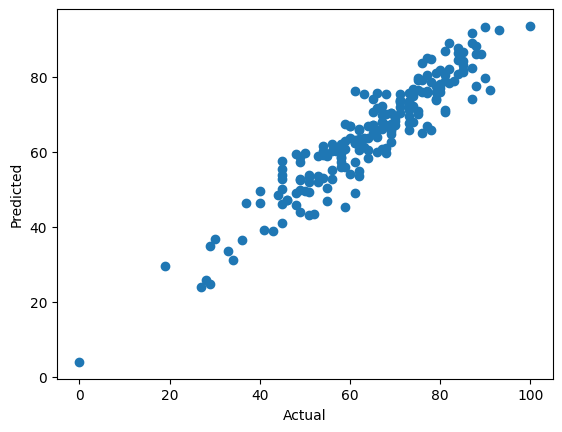

In [48]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

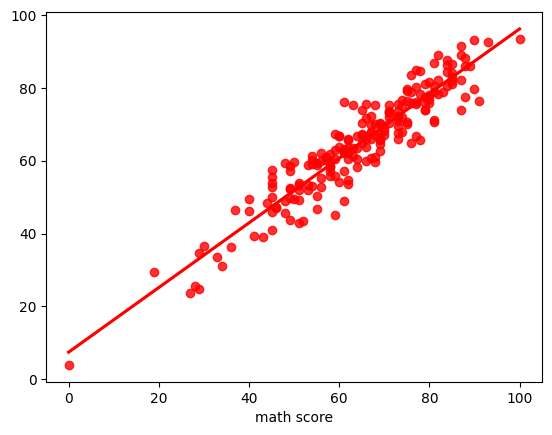

In [49]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

#### Difference between Actual and Predicted Values

In [50]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.398705,14.601295
737,53,58.842469,-5.842469
740,80,76.992129,3.007871
660,74,76.805898,-2.805898
411,84,87.615387,-3.615387
...,...,...,...
408,52,43.492293,8.507707
332,62,62.170763,-0.170763
208,74,67.910325,6.089675
613,65,67.061504,-2.061504
